<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/23_WeightInitializationNonZero_verysmall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import Adam

from mlxtend.plotting import plot_decision_regions

In [3]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/DeepLearning/master/ushape.csv")
df = df.round(2)
df.head()

,X,Y,class
0,0.03,0.99,0.0
1,2.12,-0.05,1.0
2,0.88,-0.08,0.0
3,-0.06,-0.04,1.0
4,0.83,-0.54,1.0


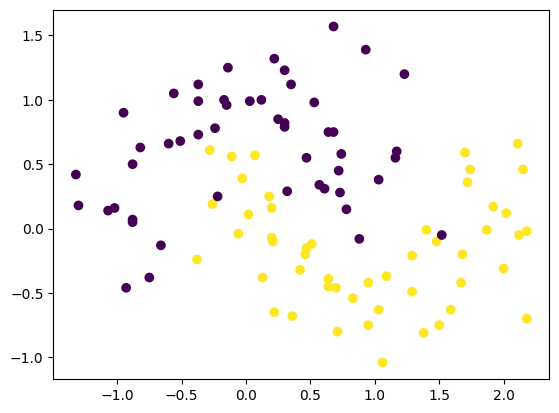

In [4]:
plt.scatter(df['X'], df['Y'], c=df['class'])

In [5]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [7]:
model=Sequential()


model.add(Dense(2, activation='tanh', input_dim=2))
model.add(Dense(2, activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.get_weights()

[array([[0.13379884, 0.92855275],
        [0.58826447, 0.9942125 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.9021665 , -0.5693997 ],
        [-1.1850957 , -0.05144989]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.6385671 , -0.68933076],
        [ 1.1412295 ,  0.948928  ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.06522071,  0.3192737 ],
        [-0.5057424 ,  1.1879746 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.15959668],
        [-1.1719009 ]], dtype=float32),
 array([0.], dtype=float32)]

In [17]:
initial_weights = model.get_weights()

In [25]:
initial_weights[0]=np.random.randn(initial_weights[0].shape[0],initial_weights[0].shape[1])*0.01
initial_weights[1]=np.zeros(initial_weights[1].shape)
initial_weights[2]=np.random.randn(initial_weights[2].shape[0],initial_weights[2].shape[1])*0.01
initial_weights[3]=np.zeros(initial_weights[3].shape)
initial_weights[4]=np.random.randn(initial_weights[4].shape[0],initial_weights[4].shape[1])*0.01
initial_weights[5]=np.zeros(initial_weights[5].shape)
initial_weights[6]=np.random.randn(initial_weights[6].shape[0],initial_weights[6].shape[1])*0.01
initial_weights[7]=np.zeros(initial_weights[7].shape)
initial_weights[8]=np.random.randn(initial_weights[8].shape[0],initial_weights[8].shape[1])*0.01
initial_weights[9]=np.zeros(initial_weights[9].shape)

In [26]:
initial_weights[0]

array([[ 0.00413782, -0.00349354],
       [ 0.00519398,  0.02204224]])

In [27]:
model.set_weights(initial_weights)

In [28]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4500 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [30]:
model.get_weights()

[array([[ 0.00486164, -0.00325535],
        [ 0.00448795,  0.02181444]], dtype=float32),
 array([-5.8543101e-06,  1.4385139e-06], dtype=float32),
 array([[ 0.01859576, -0.00372469],
        [ 0.00376367,  0.00559845]], dtype=float32),
 array([-0.00020723,  0.00037988], dtype=float32),
 array([[ 0.01898311,  0.01173104],
        [ 0.00458519, -0.01089933]], dtype=float32),
 array([ 0.00057671, -0.00513407], dtype=float32),
 array([[ 0.00113483,  0.01044812],
        [-0.00514723, -0.00056384]], dtype=float32),
 array([6.9035585e-03, 1.5131858e-05], dtype=float32),
 array([[7.829036e-03],
        [3.625689e-05]], dtype=float32),
 array([-0.00522571], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 813us/step


<Axes: >

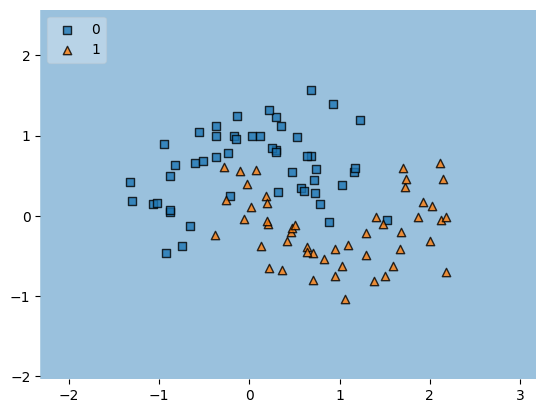

In [31]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values,y.values.astype('int'), clf=model, legend=2)
